[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatheusSilveiraVicente/case-especialista-dados/blob/main/notebooks/02_comportamento_consumo.ipynb)

# 02 — Comportamento de consumo: o que o dado sugere para o negócio

A análise exploratória (notebook 01) mostrou **quando** se vende. Aqui a pergunta é **como o consumidor reage**: a desconto, a datas de presente e ao salário.

**Leia com esta ressalva:** a base é agregada por hora, canal e categoria, sem cliente, campanha ou margem. Os resultados são **associações controladas por calendário**, ou seja, hipóteses fortes para levar ao negócio, não efeitos causais provados.

In [1]:
# Setup: roda localmente ou no Google Colab
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "MatheusSilveiraVicente/case-especialista-dados"

if IN_COLAB:
    pasta = Path("/content/case-especialista-dados")
    if not pasta.exists():
        url = f"https://github.com/{REPO}.git"
        try:  # repositório privado: crie o segredo GITHUB_TOKEN (somente leitura) no painel de chaves do Colab
            from google.colab import userdata
            url = f"https://{userdata.get('GITHUB_TOKEN')}@github.com/{REPO}.git"
        except Exception:
            pass
        subprocess.run(["git", "clone", "-q", url, str(pasta)], check=True, capture_output=True)
    os.chdir(pasta)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna", "holidays", "shap", "lightgbm", "xgboost", "statsmodels", "pyarrow"], check=True)
    if not Path("data/raw/vendas.csv").exists():
        from google.colab import files
        print("Envie o CSV do case (Dados - Case Técnico Espec I.csv):")
        enviado = files.upload()
        Path("data/raw").mkdir(parents=True, exist_ok=True)
        Path(next(iter(enviado))).rename("data/raw/vendas.csv")
elif Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Ambiente:", "Colab" if IN_COLAB else "local")

import warnings; warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, display
from src import consumo
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
r = consumo.gerar_todas()

Ambiente: local


## 1. Quanto o desconto move a venda

Regressão diária: cada indicador (em log) contra a taxa de desconto, controlando dia da semana e mês, com erros robustos à autocorrelação. O resultado é a variação associada a **+1 ponto percentual de desconto**.

,indicador,efeito_pct,ic_baixo_pct,ic_alto_pct,p_valor
0,Pedidos,2.77,1.75,3.81,0.00
1,Itens por pedido,0.77,0.44,1.09,0.00
2,Preço por item,-1.90,-2.48,-1.31,0.00
3,Ticket médio,-1.15,-1.56,-0.73,0.00
4,Receita,1.59,0.66,2.53,0.00


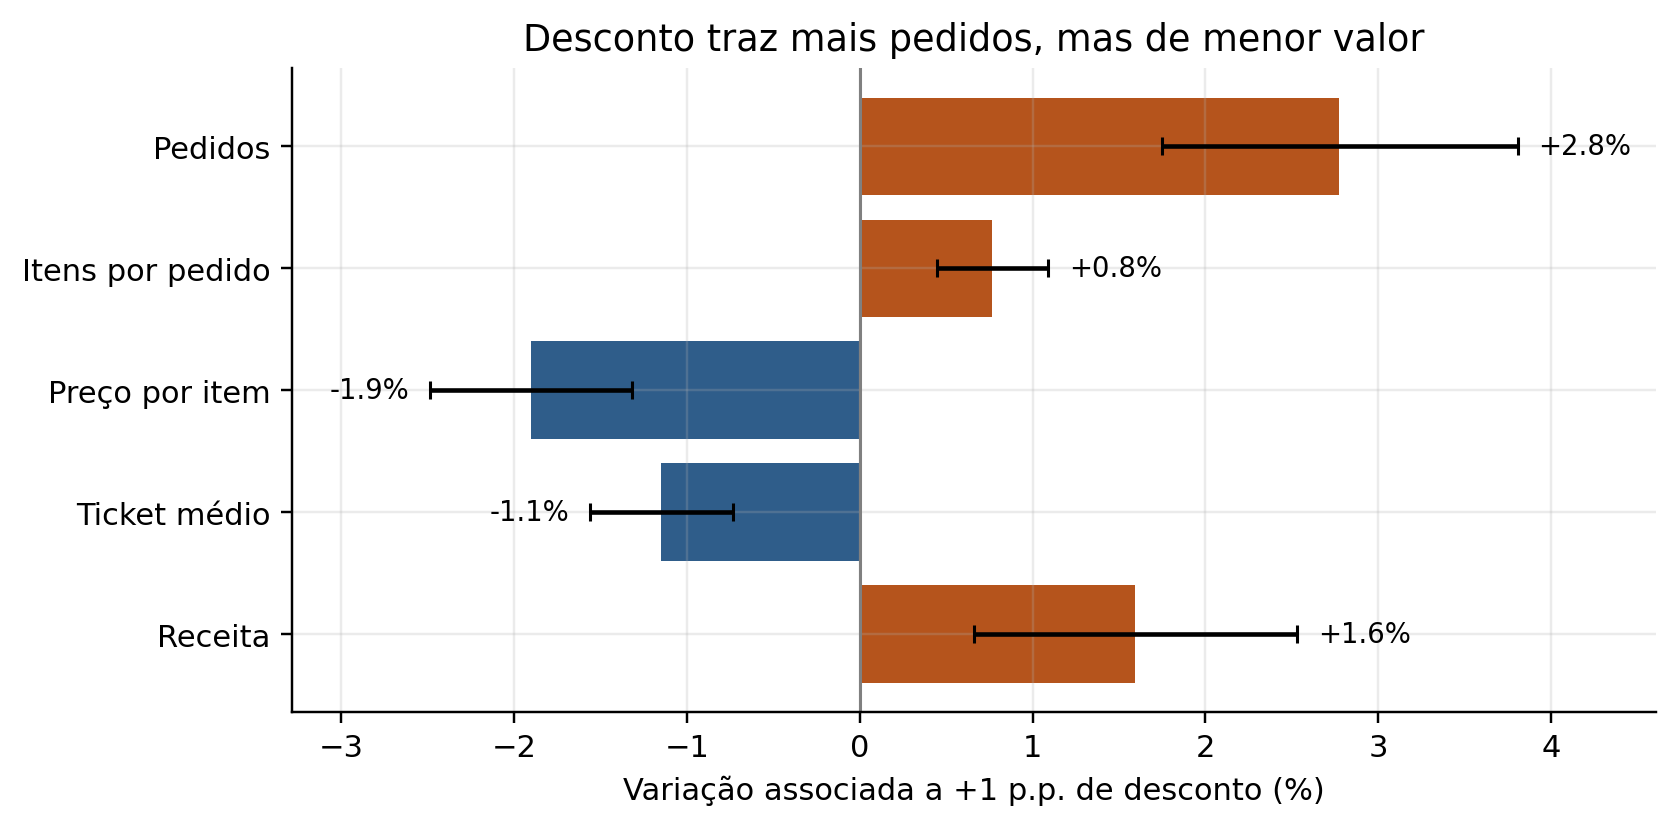

In [2]:
display(r["sensibilidade"])
display(Image("reports/figures/consumo_01_sensibilidade_desconto.png"))

**Leitura de negócio**
- Cada ponto a mais de desconto vem acompanhado de **+2,8% de pedidos** e **+0,8% de itens por pedido**, mas **−1,9% no preço pago por item**. A receita líquida cresce bem menos que os pedidos (**+1,6%**).
- O desconto compra volume, não valor. Se ele vale a pena depende da **margem**, que a base não tem. É a primeira pergunta para levar ao time comercial.
- Ressalva: dias de desconto alto também têm mídia e campanha. Parte desse efeito é da campanha inteira, não só do preço.

## 2. A promoção antecipa a demanda das semanas seguintes?

In [3]:
display(r["semanal"])

,coeficiente,p_valor
taxa,1.14,0.33
taxa_sem_1,0.77,0.61
taxa_sem_2,1.08,0.36


**Leitura de negócio**
- Se a promoção só antecipasse compras, semanas com desconto alto seriam seguidas por semanas mais fracas (coeficientes negativos nas defasagens). **Não é o que aparece:** os coeficientes são positivos e não significativos. Não há sinal de "ressaca" semanal.
- O vale de fevereiro (R$ 1,24 mi/dia, o menor mês) é compatível com a sazonalidade de início de ano (gastos fixos das famílias), mas, sem o ano anterior, não dá para separar esse efeito de uma ressaca de longo prazo da Black Friday.

## 3. O que o consumidor compra quando há promoção

faixa,baixo,médio,alto
categoria,,,
CABELOS,3.43,3.38,3.77
CORPO E BANHO,17.71,16.95,13.71
FACIAL,1.45,1.38,2.29
GIFTS,14.01,11.74,7.03
MAQUIAGEM,4.25,3.68,3.76
PERF. DE ENTRADA E DEOS,13.62,12.79,9.59
PERFUMARIA FEMININA,19.94,22.96,29.98
PERFUMARIA MASCULINA,25.59,27.12,29.87


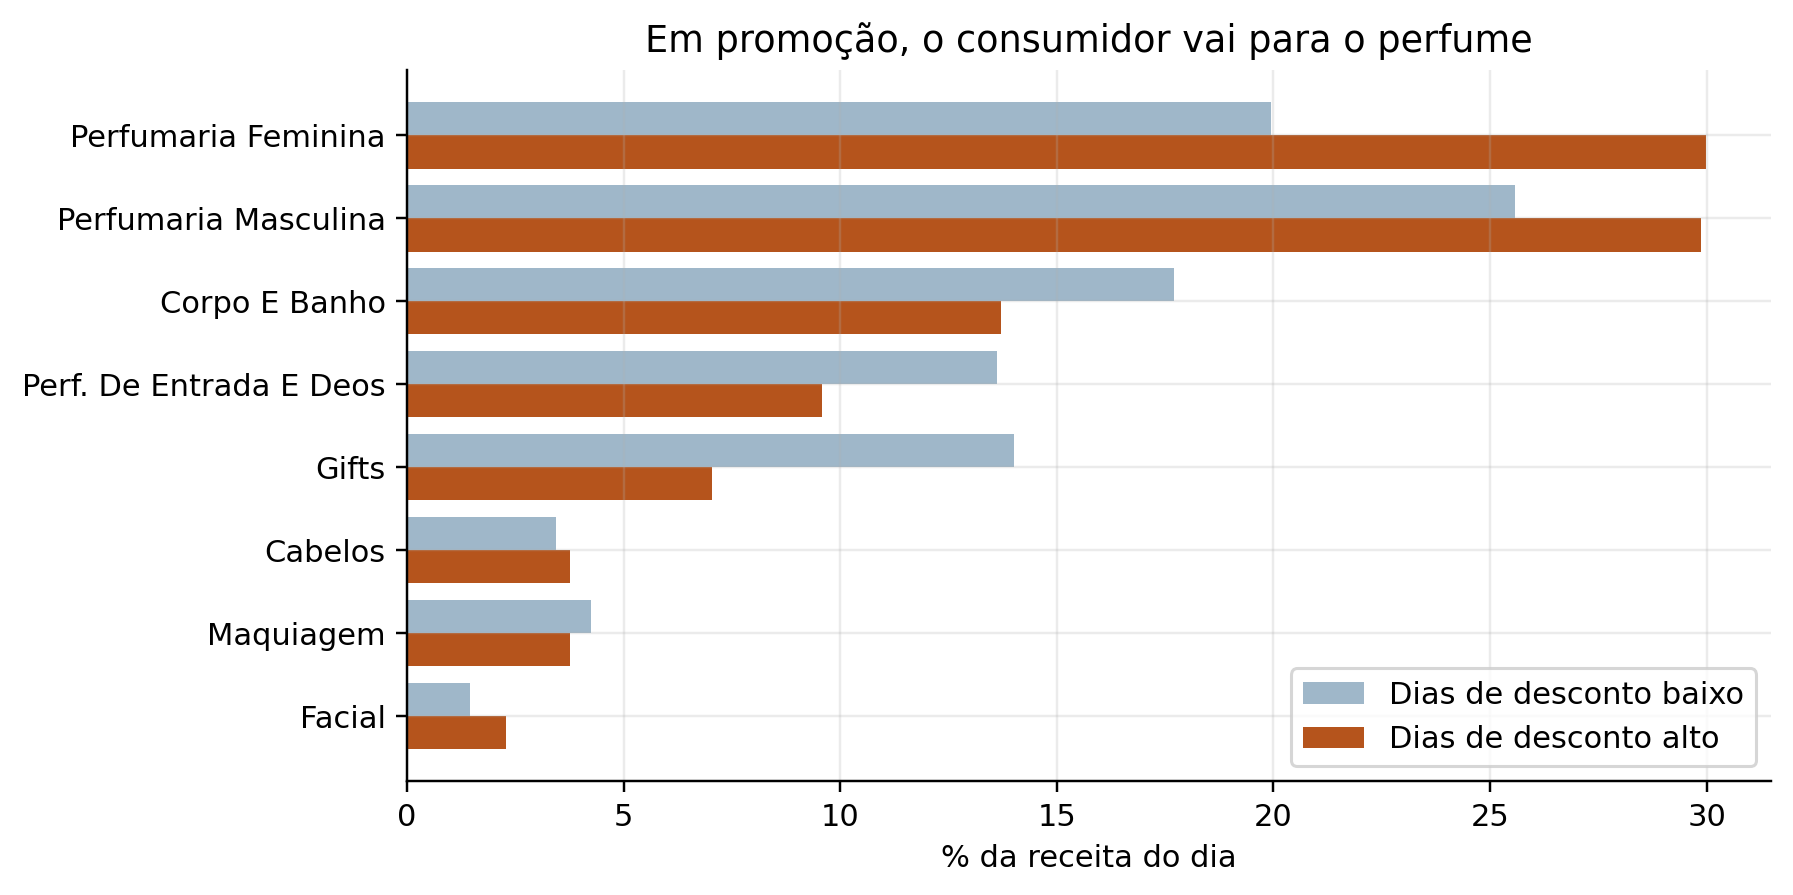

In [4]:
display(r["mix"])
display(Image("reports/figures/consumo_02_mix_promocao.png"))

**Leitura de negócio**
- Nos dias de desconto alto, **perfumaria (feminina + masculina) sobe de 46% para 60% da receita**. Gifts cai pela metade (14% → 7%) e corpo e banho também perde espaço.
- A promoção funciona como um **evento de perfume**: o consumidor aproveita o desconto para comprar o item de maior valor da marca.
- Gifts se comporta ao contrário: vende por ocasião, não por preço. Desconto em kit de presente tende a ser dinheiro deixado na mesa.

## 4. Onde está o desconto

In [5]:
display(r["categorias"])

,taxa_desconto,preco_cheio_por_item,preco_pago_por_item,participacao_receita
categoria,,,,
PERF. DE ENTRADA E DEOS,0.29,59.39,42.29,0.11
GIFTS,0.32,152.78,104.06,0.11
CORPO E BANHO,0.42,58.68,33.92,0.16
PERFUMARIA MASCULINA,0.43,131.72,74.94,0.27
CABELOS,0.44,44.42,25.05,0.04
MAQUIAGEM,0.45,53.23,29.43,0.04
PERFUMARIA FEMININA,0.51,113.16,56.00,0.26
FACIAL,0.65,55.41,19.37,0.02


**Leitura de negócio**
- **Facial tem o maior desconto (65%) e o menor preço por item**, com só ~2% da receita. Vale revisar: desconto alto num item barato pode não trazer venda incremental.
- **Perfumaria feminina** combina desconto alto (~50%) com ~26% da receita: é a principal alavanca promocional.
- Gifts e perfumes de entrada vendem com o menor desconto (~30%), o que é coerente com a compra por ocasião vista acima.

## 5. O ticket subiu por menos desconto ou por produto mais caro?

In [6]:
display(r["preco_item"])

,preco_pago_por_item,preco_cheio_por_item
data,,
2025-11,35.89,79.67
2025-12,55.02,88.08
2026-01,58.37,103.44
2026-02,54.61,85.59
2026-03,52.56,88.64
2026-04,57.60,85.39
2026-05,62.19,101.26
2026-06,60.61,93.06


**Leitura de negócio**
- O preço **pago** por item subiu de R$ 36 (novembro) para R$ 61 (junho). Mas o preço **cheio** por item, antes do desconto, também subiu, de R$ 80 para R$ 93, com picos em janeiro e maio.
- O aumento do ticket tem **duas causas**: menos desconto e um **mix de produtos mais caros**. Os picos de preço cheio em maio coincidem com o Dia das Mães (kits e perfumes de presente).

## 6. O presente tem destinatário

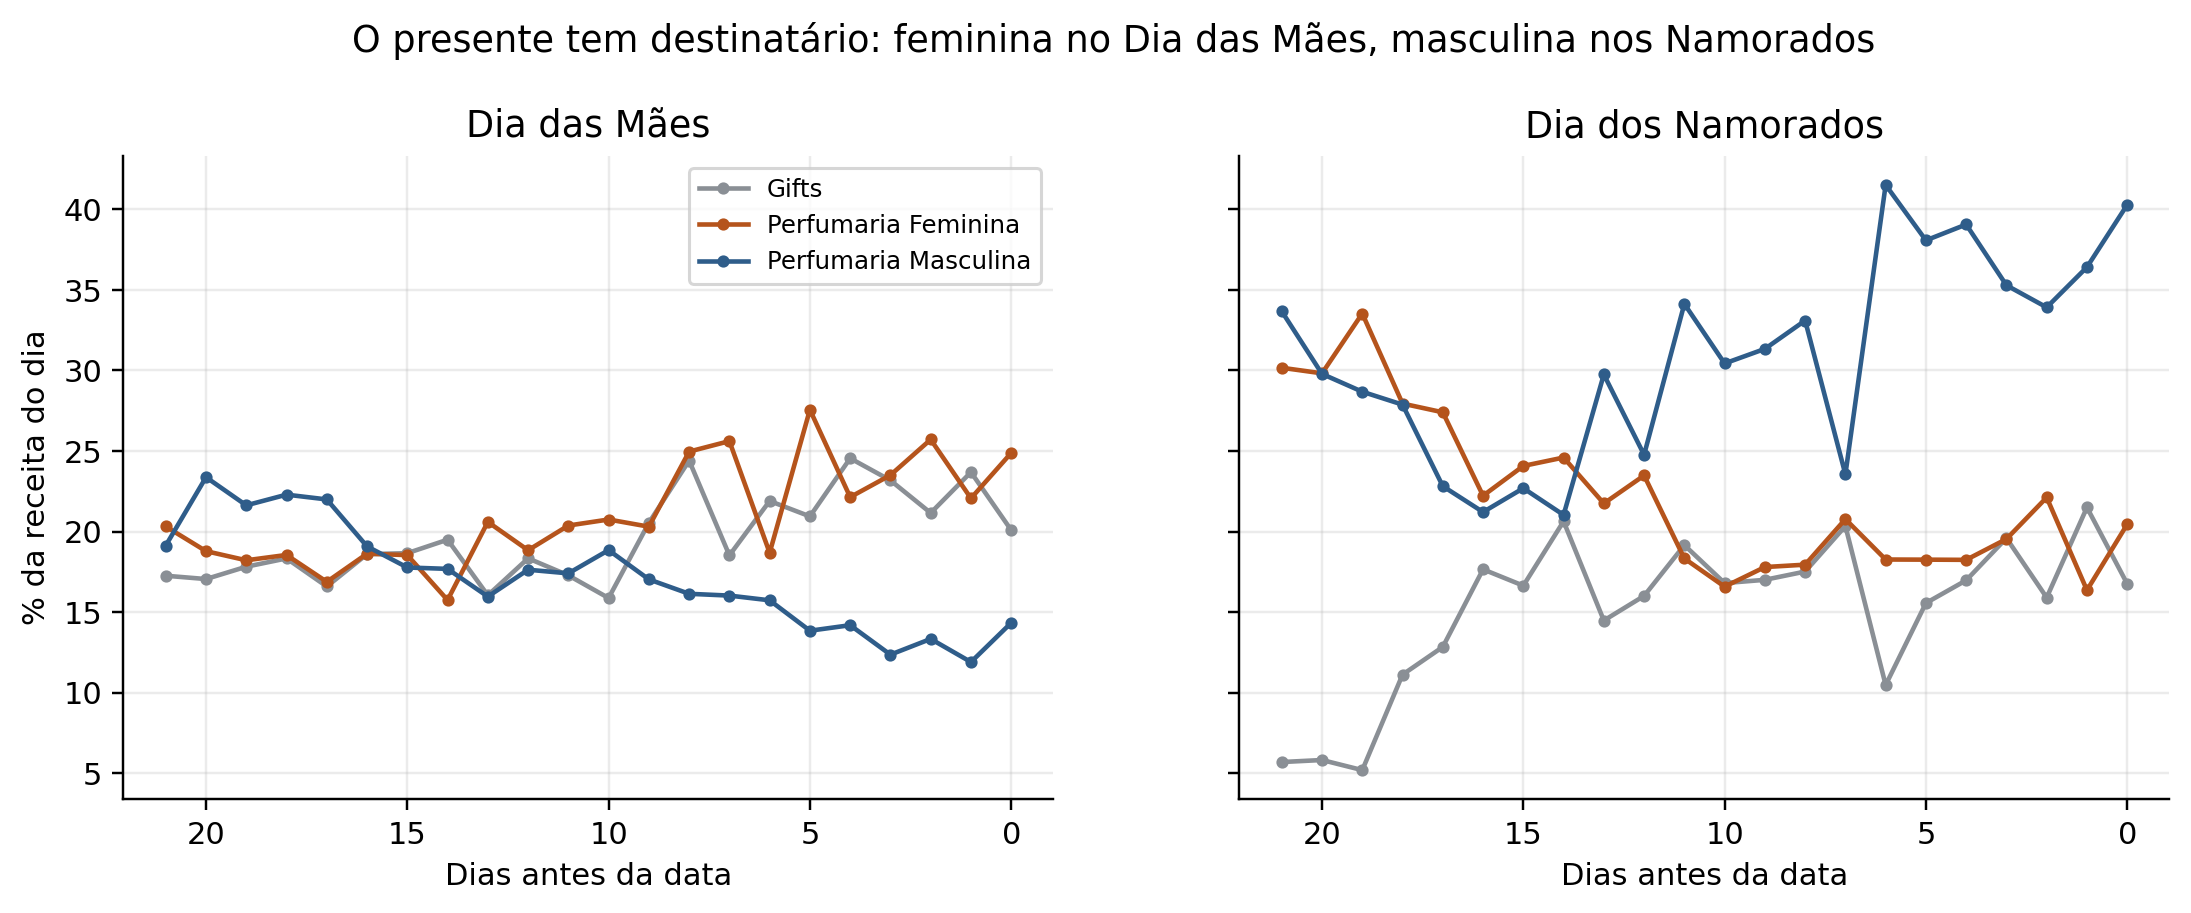

In [7]:
display(Image("reports/figures/consumo_03_presente.png"))

**Leitura de negócio**
- Na semana anterior ao **Dia das Mães**, a perfumaria feminina sobe para ~25% da receita e a masculina cai para ~13%.
- Na semana anterior ao **Dia dos Namorados**, a perfumaria masculina dispara para **34%–42%** da receita.
- O e-commerce mostra **para quem** o consumidor está comprando. Uso prático: banner, CRM e estoque por destinatário do presente, começando cerca de uma semana antes da data, quando a curva acelera.

## 7. Salário por canal

In [8]:
display(r["salario"])

dias_5_a_7,False,True
canal,,
App,0.98,1.17
Site,0.97,1.23


**Leitura de negócio**
- Nos dias 5 a 7, a receita fica **+23% no Site** e **+17% no App** acima do esperado para o dia da semana e o mês.
- O início do mês é a janela natural para comunicação de produtos de maior valor, principalmente no Site.

## Resumo para o negócio

1. Desconto compra volume, não valor: +2,8% de pedidos, −1,9% de preço por item por ponto de desconto. A decisão depende da margem.
2. Não há sinal de ressaca semanal depois de promoções.
3. Promoção é evento de perfume; Gifts vende por ocasião, não por preço.
4. Facial: desconto mais alto da base num item de baixo valor. Candidato a revisão.
5. O ticket sobe por menos desconto e por mix mais caro.
6. O presente tem destinatário: feminina no Dia das Mães, masculina nos Namorados.
7. Salário move o Site mais que o App.

**Dados que a empresa tem e que transformariam essas hipóteses em respostas:** margem por categoria, calendário de campanhas e mídia, dados de cliente (recorrência, quem compra para quem) e ruptura de estoque.